# Project 8- Student Performance & GenAI Prediction

## Project 1: Data Overview

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(r"C:\Users\Admin\Desktop\github\python-data-science-handbook\Projects\data\ai_student_impact_dataset (1).csv")
df.head()
df

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,149996,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,149997,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,149998,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,149999,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium


In [5]:
df.columns

Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

## Task 2: Data Quality Check

In [8]:
df.isnull().sum()

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

## Task 3: Understanding the Target Variable

In [10]:
df["Post_Semester_GPA"].mean()

np.float64(3.3492994200000004)

In [11]:
df["Post_Semester_GPA"].median()

np.float64(3.421)

In [13]:
print(df["Post_Semester_GPA"].min())
print(df["Post_Semester_GPA"].max())

1.0
4.0


In [14]:
mean = df["Post_Semester_GPA"].mean()
median = df["Post_Semester_GPA"].median()

print(mean)
print(median)

3.3492994200000004
3.421


## Task 4: Distribution Analysis

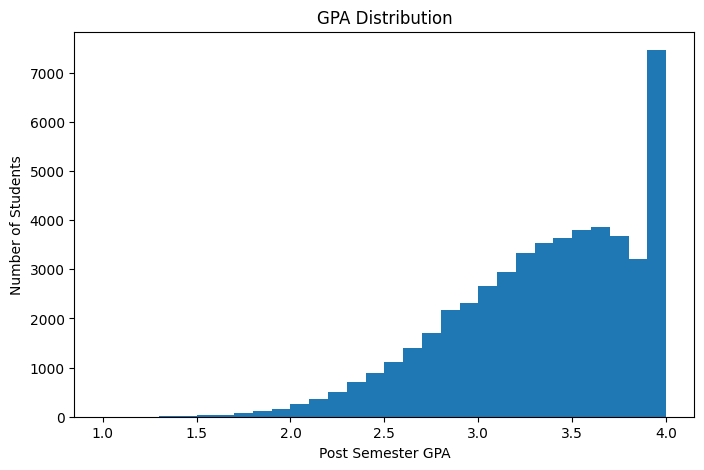

In [19]:
plt.figure(figsize=(8,5))

plt.hist(df["Post_Semester_GPA"], bins=30)

plt.xlabel("Post Semester GPA")
plt.ylabel("Number of Students")

plt.title("GPA Distribution")

plt.show()

## Task 5: Academic Progress

In [21]:
df["GPA_Change"] = ( df["Post_Semester_GPA"] - df["Pre_Semester_GPA"])
df

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,GPA_Change
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High,-0.025
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low,-0.125
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium,0.101
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium,0.211
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium,0.163
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,149996,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High,0.685
49996,149997,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium,0.226
49997,149998,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High,0.428
49998,149999,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium,0.129


In [22]:
df["GPA_Change"].max()

np.float64(1.008)

In [23]:
df["GPA_Change"].min()

np.float64(-0.9239999999999999)

In [24]:
df["GPA_Change"].mean()

np.float64(0.20319708000000003)

## Task 6

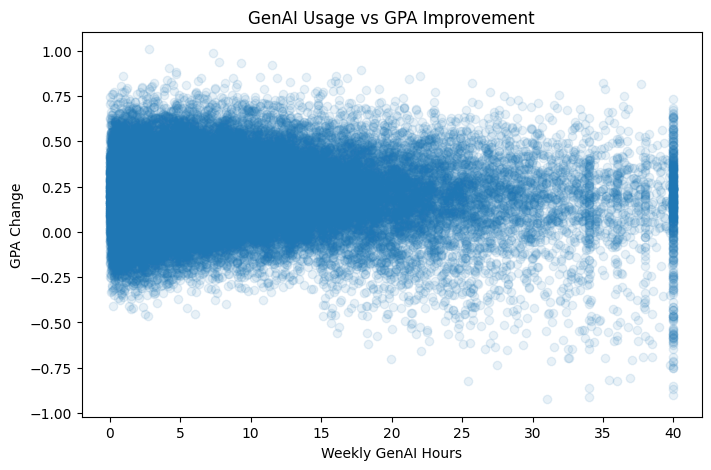

In [26]:
plt.figure(figsize=(8,5))

plt.scatter(df["Weekly_GenAI_Hours"], df["GPA_Change"], alpha=0.1)

plt.xlabel("Weekly GenAI Hours")
plt.ylabel("GPA Change")

plt.title("GenAI Usage vs GPA Improvement")

plt.show()

## Task 7: Traditional Study Hours Analysis

In [27]:
df["Traditional_Study_Hours"].mean()

np.float64(11.209271000000001)

In [28]:
df.loc[df["Traditional_Study_Hours"].idxmax()]

Student_ID                                   120111
Major_Category                              Medical
Year_of_Study                              Freshman
Pre_Semester_GPA                              3.038
Weekly_GenAI_Hours                             0.09
Primary_Use_Case                           Ideation
Prompt_Engineering_Skill                   Beginner
Tool_Diversity                                    3
Paid_Subscription                              True
Traditional_Study_Hours                       35.86
Perceived_AI_Dependency                           3
Institutional_Policy          Allowed_With_Citation
Anxiety_Level_During_Exams                        5
Post_Semester_GPA                             3.753
Skill_Retention_Score                         73.13
Burnout_Risk_Level                              Low
GPA_Change                                    0.715
Name: 20110, dtype: object

## Task 8: Primary Use Case Investigation

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [31]:
df["Primary_Use_Case"].value_counts()

Primary_Use_Case
Debugging/Troubleshooting    12295
Copywriting/Drafting         12011
Ideation                     10721
Summarizing_Reading           8633
Direct_Answer_Generation      6340
Name: count, dtype: int64

In [33]:
df.groupby("Primary_Use_Case")["Post_Semester_GPA"].mean()

Primary_Use_Case
Copywriting/Drafting         3.335306
Debugging/Troubleshooting    3.395840
Direct_Answer_Generation     3.294164
Ideation                     3.343697
Summarizing_Reading          3.349935
Name: Post_Semester_GPA, dtype: float64

In [35]:
df.groupby("Primary_Use_Case")["Skill_Retention_Score"].mean()

Primary_Use_Case
Copywriting/Drafting         75.231097
Debugging/Troubleshooting    78.068964
Direct_Answer_Generation     73.718877
Ideation                     75.520224
Summarizing_Reading          75.225024
Name: Skill_Retention_Score, dtype: float64

## Task 9: Paid Subscription Analysis

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [38]:
df["Paid_Subscription"].value_counts()

Paid_Subscription
False    28846
True     21154
Name: count, dtype: int64

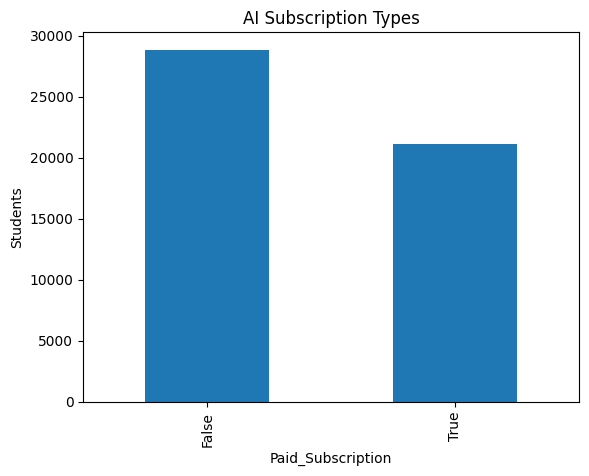

In [40]:
df["Paid_Subscription"].value_counts().plot(kind="bar")

plt.title("AI Subscription Types")
plt.ylabel("Students")

plt.show()

In [42]:
df.groupby("Paid_Subscription")["Post_Semester_GPA"].mean()

Paid_Subscription
False    3.346953
True     3.352499
Name: Post_Semester_GPA, dtype: float64

## Task 10: Maor Caterory Analysis

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [44]:
df["Major_Category"].value_counts()

Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64

In [45]:
df.groupby("Major_Category")["Weekly_GenAI_Hours"].mean()

Major_Category
Arts           7.271702
Business       8.275898
Humanities     6.770144
Medical        7.546728
STEM          10.488609
Name: Weekly_GenAI_Hours, dtype: float64

## Task 11: Correlation Study

In [47]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

correlation

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,GPA_Change
Student_ID,1.000000,0.002275,0.001577,-0.001187,0.000648,0.002768,0.009670,-0.000602,-0.001737,-0.007413
Pre_Semester_GPA,0.002275,1.000000,-0.001084,-0.005671,-0.004620,0.000701,-0.000667,0.926781,0.099019,-0.104035
Weekly_GenAI_Hours,0.001577,-0.001084,1.000000,0.008411,-0.157368,0.665479,0.269080,-0.018600,-0.118099,-0.046479
Tool_Diversity,-0.001187,-0.005671,0.008411,1.000000,0.003565,0.006019,0.003189,0.025265,0.196952,0.081407
Traditional_Study_Hours,0.000648,-0.004620,-0.157368,0.003565,1.000000,-0.102625,-0.040935,0.137653,0.147565,0.376317
Perceived_AI_Dependency,0.002768,0.000701,0.665479,0.006019,-0.102625,1.000000,0.307620,-0.014180,-0.084324,-0.039342
Anxiety_Level_During_Exams,0.009670,-0.000667,0.269080,0.003189,-0.040935,0.307620,1.000000,-0.015909,-0.041556,-0.040420
Post_Semester_GPA,-0.000602,0.926781,-0.018600,0.025265,0.137653,-0.014180,-0.015909,1.000000,0.169616,0.277146
Skill_Retention_Score,-0.001737,0.099019,-0.118099,0.196952,0.147565,-0.084324,-0.041556,0.169616,1.000000,0.195833
GPA_Change,-0.007413,-0.104035,-0.046479,0.081407,0.376317,-0.039342,-0.040420,0.277146,0.195833,1.000000


In [48]:
correlation["Post_Semester_GPA"].sort_values()

Weekly_GenAI_Hours           -0.018600
Anxiety_Level_During_Exams   -0.015909
Perceived_AI_Dependency      -0.014180
Student_ID                   -0.000602
Tool_Diversity                0.025265
Traditional_Study_Hours       0.137653
Skill_Retention_Score         0.169616
GPA_Change                    0.277146
Pre_Semester_GPA              0.926781
Post_Semester_GPA             1.000000
Name: Post_Semester_GPA, dtype: float64

In [49]:
correlation["Skill_Retention_Score"].sort_values()

Weekly_GenAI_Hours           -0.118099
Perceived_AI_Dependency      -0.084324
Anxiety_Level_During_Exams   -0.041556
Student_ID                   -0.001737
Pre_Semester_GPA              0.099019
Traditional_Study_Hours       0.147565
Post_Semester_GPA             0.169616
GPA_Change                    0.195833
Tool_Diversity                0.196952
Skill_Retention_Score         1.000000
Name: Skill_Retention_Score, dtype: float64

<Axes: >

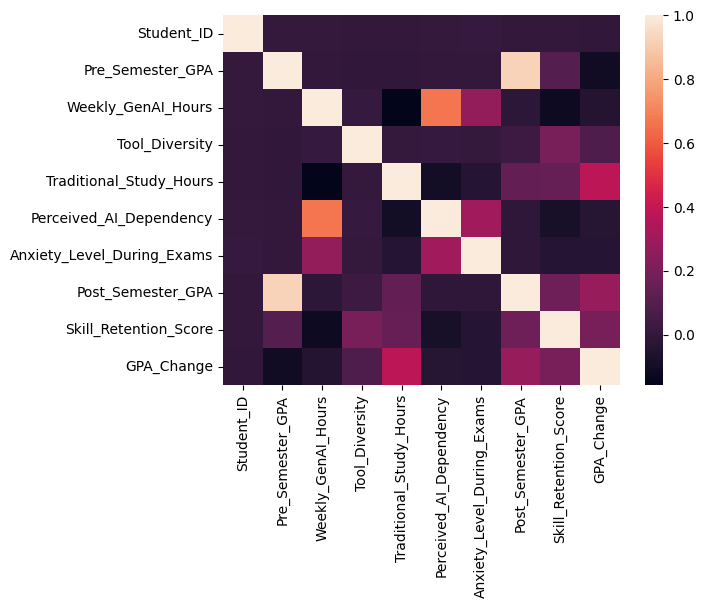

In [56]:
import seaborn as sns
sns.heatmap(correlation)

## Task 12: Outlier Detection

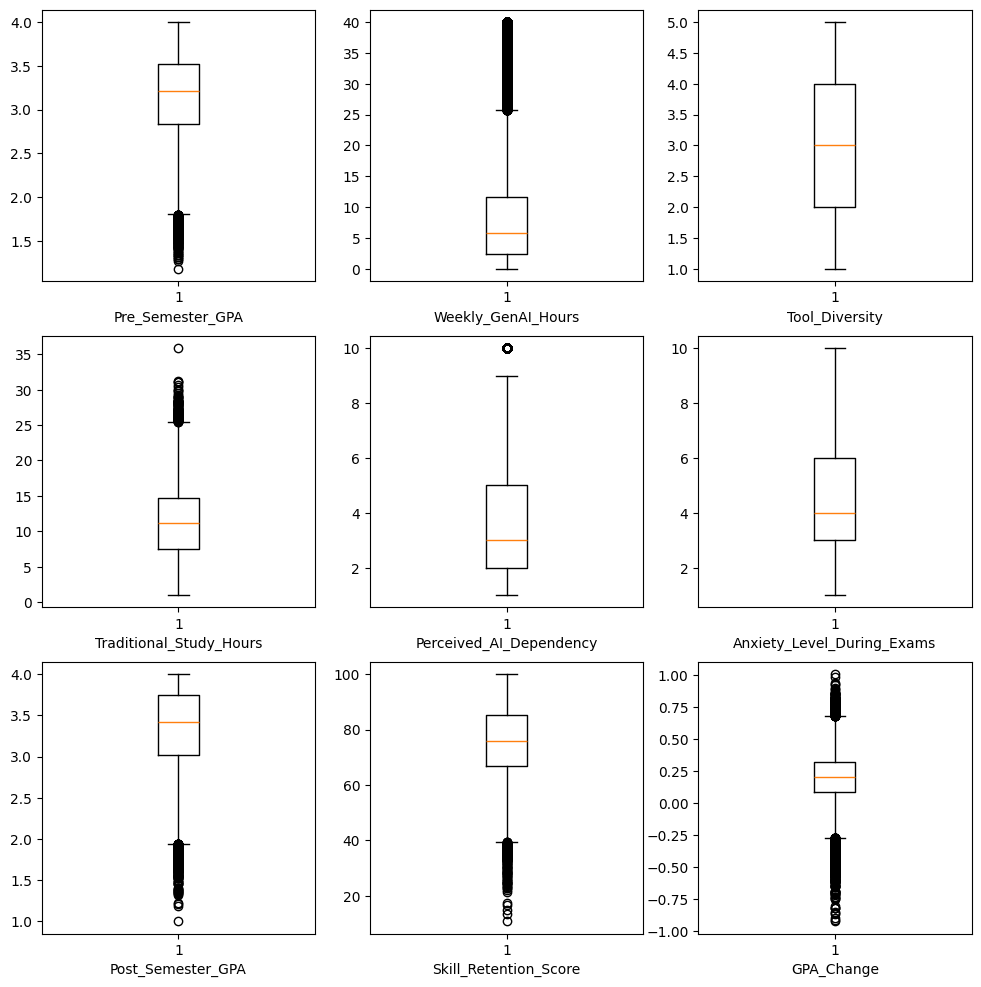

In [55]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()
for i, column in  enumerate(df.select_dtypes(include="number").columns[1:]):
    axes[i].boxplot(df[column])
    axes[i].set_xlabel(column)

In [52]:
df.select_dtypes(include="number").columns[1:]

Index(['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity',
       'Traditional_Study_Hours', 'Perceived_AI_Dependency',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'GPA_Change'],
      dtype='object')